# **KNN — Clasificación**

Objetivo: predecir si un estudiante **abandona** (1) o permanece **Enrolled** (0).

---
## **Grid Search Manual con Validación Cruzada**

Grid a explorar:

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `k` | 3, 5, 7, 9, 11 | Impares para evitar empates en votación |
| `top_n` | 5, 8, 10, 15 | Probar diferente cantidad de parametros |

Para cada combinación (`k`, `top_n`): **5-fold Stratified CV** sobre `X_trainval`, métrica guía **F1**.

Se ha decidiodo usar **F1** como metrica guia:

$$
F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Puesto que el dataset tras excluir Graduate queda desbalanceado. F1 exige que el modelo sea bueno detectando abandonos (Recall alto) sin generar demasiadas falsas alarmas (Precision aceptable). Es el compromiso más razonable para un sistema de alerta temprana con recursos limitados.

In [46]:
K_VALUES    = [3, 5, 7, 9, 11]
TOPN_VALUES = [5, 8, 10, 15]
N_SPLITS    = 5

X_trainval_raw = pd.concat([X_train_raw, X_val_raw]).reset_index(drop=True)
y_clf_trainval = np.concatenate([y_clf_train, y_clf_val])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_results = []

total_combos = len(K_VALUES) * len(TOPN_VALUES)
print(f"Grid Search: {total_combos} combinaciones × {N_SPLITS} folds = "
      f"{total_combos * N_SPLITS} fits\n")
print(f"{'top_n':>6}  {'k':>4}  {'F1 fold1':>9} {'F1 fold2':>9} "
      f"{'F1 fold3':>9} {'F1 fold4':>9} {'F1 fold5':>9}  {'Media':>8}  {'Std':>7}")
print("─" * 85)

for top_n in TOPN_VALUES:
    for k in K_VALUES:
        fold_scores = []
        for train_idx, val_idx in skf.split(X_trainval_raw, y_clf_trainval):
            pipe = make_clf_pipeline(k, top_n)
            pipe.fit(X_trainval_raw.iloc[train_idx], y_clf_trainval[train_idx])
            fold_scores.append(f1_score(
                y_clf_trainval[val_idx],
                pipe.predict(X_trainval_raw.iloc[val_idx]),
                zero_division=0
            ))

        cv_results.append({
            "top_n"   : top_n,
            "k"       : k,
            "F1_media": np.mean(fold_scores),
            "F1_std"  : np.std(fold_scores),
        })
        folds_str = "  ".join([f"{s:.4f}" for s in fold_scores])
        print(f"{top_n:>6}  {k:>4}  {folds_str}  "
              f"{np.mean(fold_scores):>8.4f}  {np.std(fold_scores):>7.4f}")
    print()

df_cv = pd.DataFrame(cv_results)

best_row       = df_cv.loc[df_cv["F1_media"].idxmax()]
best_k         = int(best_row["k"])
best_top_n     = int(best_row["top_n"])

print(f"\n→ Mejor combinación:")
print(f"   k*     = {best_k}")
print(f"   top_n* = {best_top_n}")
print(f"   F1     = {best_row['F1_media']:.4f} ± {best_row['F1_std']:.4f}")

Grid Search: 20 combinaciones × 5 folds = 100 fits

 top_n     k   F1 fold1  F1 fold2  F1 fold3  F1 fold4  F1 fold5     Media      Std
─────────────────────────────────────────────────────────────────────────────────────
     5     3  0.7638  0.7900  0.7320  0.7098  0.6806    0.7352   0.0386
     5     5  0.7604  0.7808  0.7249  0.7093  0.7950    0.7541   0.0325
     5     7  0.7371  0.8017  0.7357  0.7196  0.7837    0.7556   0.0314
     5     9  0.7627  0.7984  0.7313  0.7226  0.7739    0.7578   0.0278
     5    11  0.7672  0.7801  0.7422  0.7429  0.7643    0.7593   0.0147

     8     3  0.7621  0.7817  0.7320  0.7371  0.6806    0.7387   0.0341
     8     5  0.7566  0.7826  0.7249  0.7500  0.7966    0.7622   0.0252
     8     7  0.7445  0.7867  0.7385  0.7650  0.7854    0.7640   0.0200
     8     9  0.7545  0.7815  0.7325  0.7646  0.7756    0.7617   0.0173
     8    11  0.7500  0.7851  0.7450  0.7629  0.7633    0.7613   0.0139

    10     3  0.7534  0.7686  0.7336  0.7371  0.7136    0

### Visualización del Grid Search CV

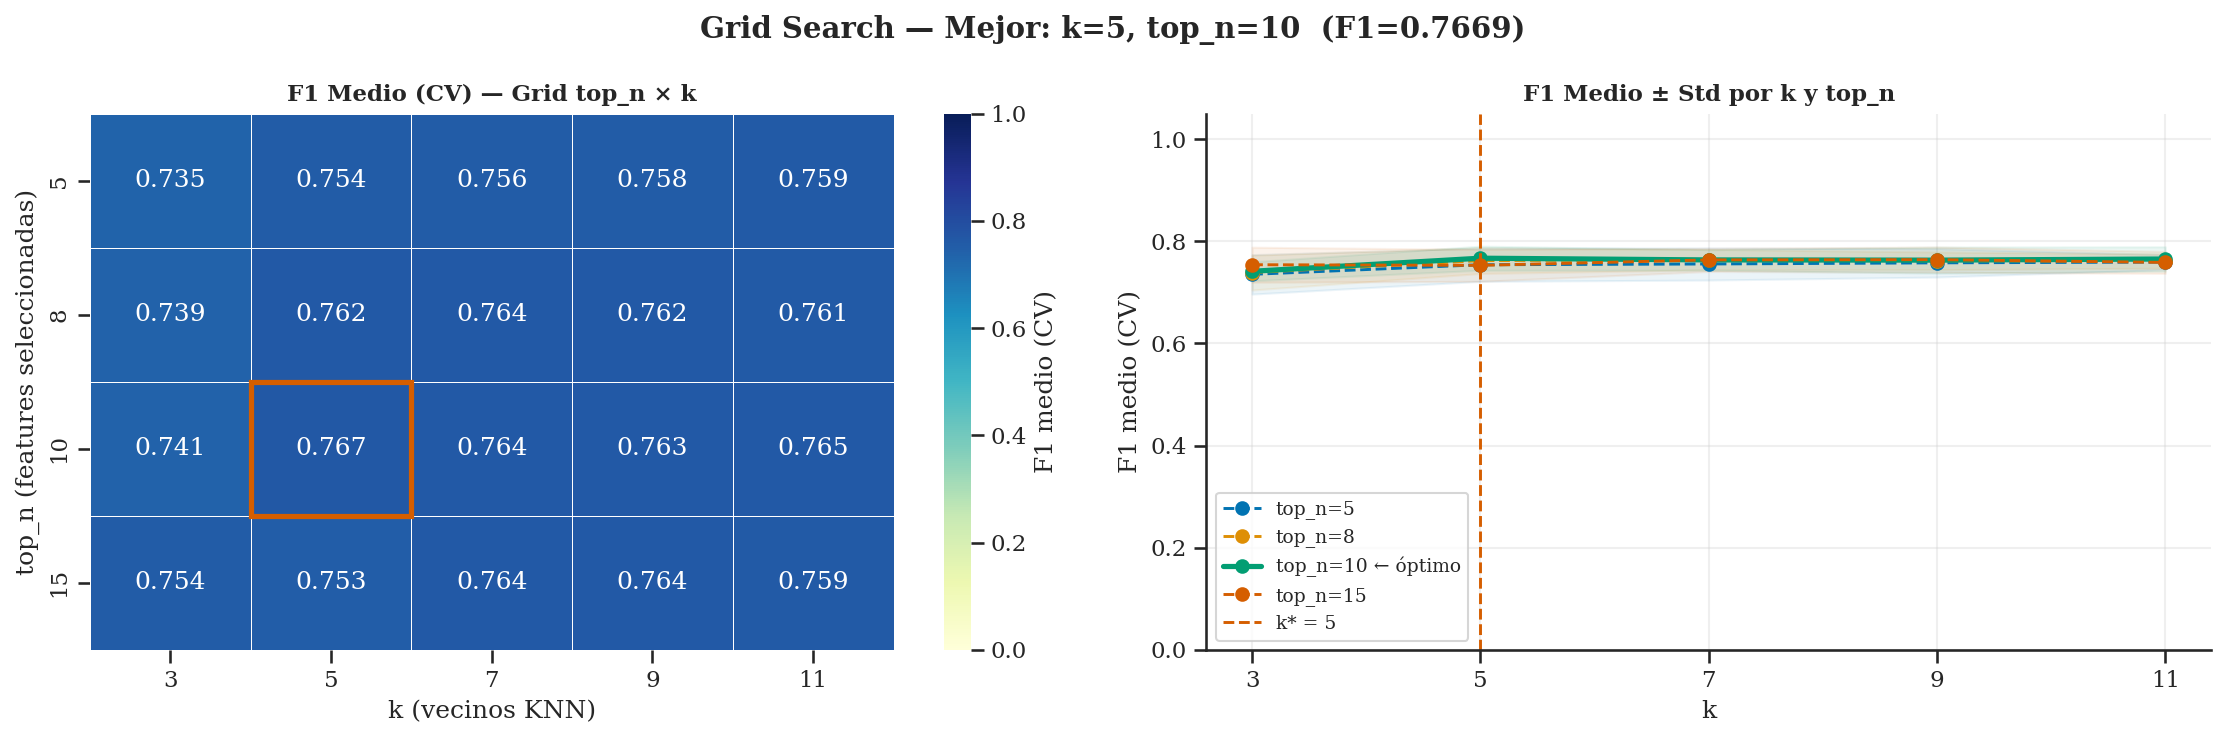

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot = df_cv.pivot(index="top_n", columns="k", values="F1_media")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap=CMAP_SEQ,
            linewidths=0.4, ax=axes[0], vmin=0, vmax=1,
            cbar_kws={"label": "F1 medio (CV)"})
best_row_idx = list(TOPN_VALUES).index(best_top_n)
best_col_idx = list(K_VALUES).index(best_k)
axes[0].add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                  fill=False, edgecolor=C_ACCENT, lw=2.5))
axes[0].set_title("F1 Medio (CV) — Grid top_n × k")
axes[0].set_xlabel("k (vecinos KNN)")
axes[0].set_ylabel("top_n (features seleccionadas)")

palette = sns.color_palette("colorblind", len(TOPN_VALUES))
for idx, top_n in enumerate(TOPN_VALUES):
    sub = df_cv[df_cv["top_n"] == top_n]
    lw = 2.5 if top_n == best_top_n else 1.4
    ls = "-"  if top_n == best_top_n else "--"
    axes[1].plot(sub["k"], sub["F1_media"],
                 marker="o", lw=lw, linestyle=ls, color=palette[idx],
                 label=f"top_n={top_n}" + (" ← óptimo" if top_n==best_top_n else ""))
    axes[1].fill_between(sub["k"],
                          sub["F1_media"] - sub["F1_std"],
                          sub["F1_media"] + sub["F1_std"],
                          alpha=0.08, color=palette[idx])

axes[1].axvline(best_k, color=C_ACCENT, linestyle="--", lw=1.4,
                label=f"k* = {best_k}")
axes[1].set(xlabel="k", ylabel="F1 medio (CV)", xticks=K_VALUES,
            ylim=(0, 1.05))
axes[1].set_title("F1 Medio ± Std por k y top_n")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

sns.despine(ax=axes[1])
plt.suptitle(f"Grid Search — Mejor: k={best_k}, top_n={best_top_n}  "
             f"(F1={best_row['F1_media']:.4f})",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## **Evaluación Final en Test**

Con `k*` elegido por CV, reentrenamos el pipeline sobre **todo X_trainval**
y evaluamos **una única vez** en test.


Evaluación en Test — KNN Clasificación (k=5, top_n=10)

  Métrica                 CV medio (F1)        Test
  ──────────────────────────────────────────────────
  Accuracy                            —      0.7020
  Balanced Accuracy                   —      0.6887
  Precision                           —      0.7857
  Recall                              —      0.7359
  F1-score                       0.7669      0.7600
  ROC AUC                             —      0.7701


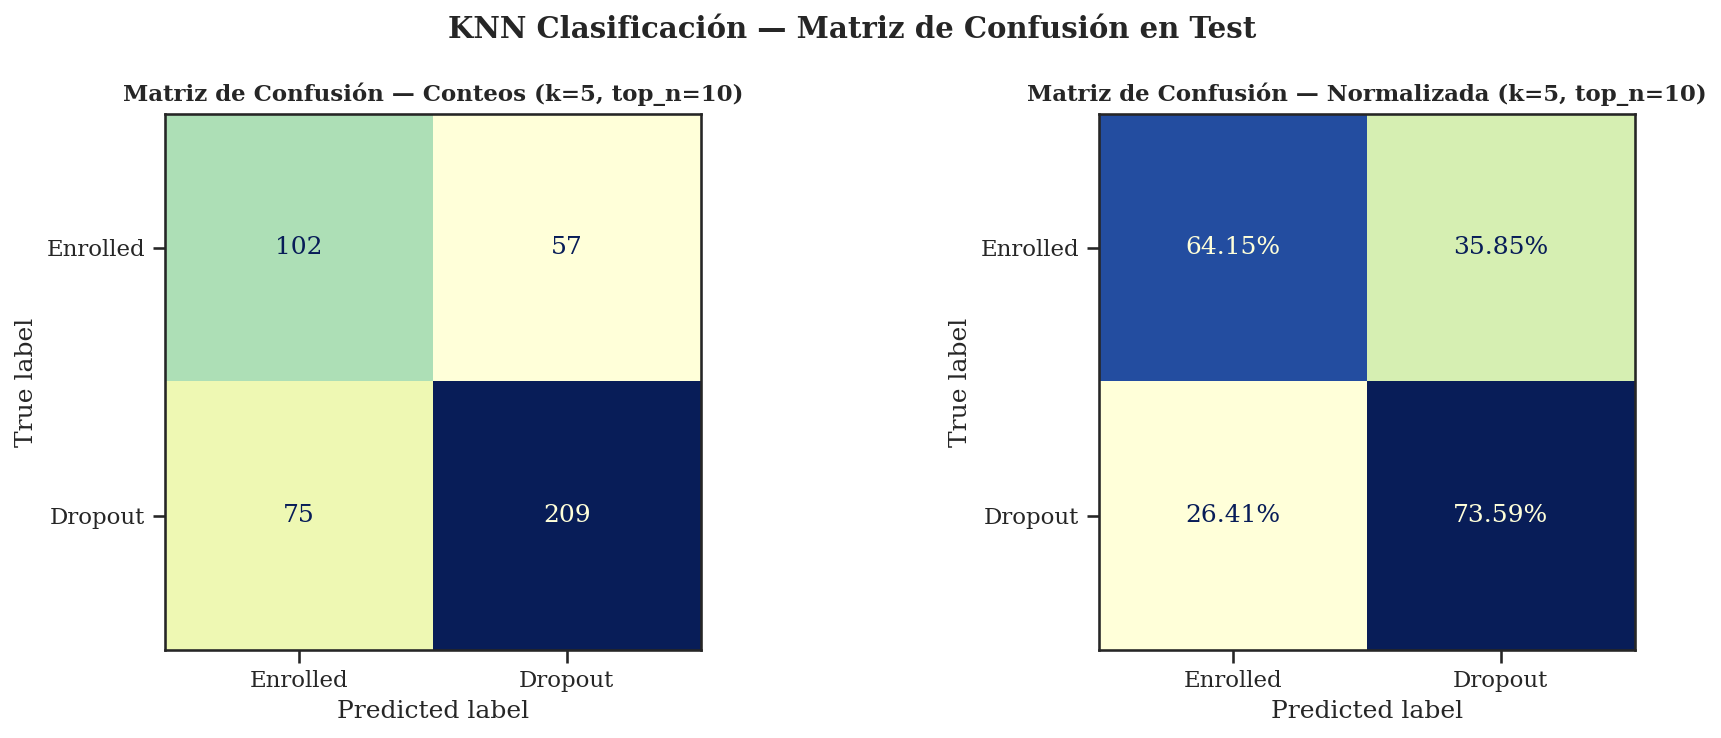


Reporte detallado:
              precision    recall  f1-score   support

    Enrolled       0.58      0.64      0.61       159
     Dropout       0.79      0.74      0.76       284

    accuracy                           0.70       443
   macro avg       0.68      0.69      0.68       443
weighted avg       0.71      0.70      0.71       443



In [48]:
pipe_best = make_clf_pipeline(best_k, best_top_n)
pipe_best.fit(X_trainval_raw, y_clf_trainval)

y_pred_test  = pipe_best.predict(X_test_raw)
y_proba_test = pipe_best.predict_proba(X_test_raw)[:, 1]

metrics_test = {
    "Accuracy"         : accuracy_score(y_clf_test, y_pred_test),
    "Balanced Accuracy": balanced_accuracy_score(y_clf_test, y_pred_test),
    "Precision"        : precision_score(y_clf_test, y_pred_test, zero_division=0),
    "Recall"           : recall_score(y_clf_test, y_pred_test, zero_division=0),
    "F1-score"         : f1_score(y_clf_test, y_pred_test, zero_division=0),
    "ROC AUC"          : roc_auc_score(y_clf_test, y_proba_test),
}

print(f"Evaluación en Test — KNN Clasificación (k={best_k}, top_n={best_top_n})\n")
print(f"  {'Métrica':<22} {'CV medio (F1)':>14}  {'Test':>10}")
print("  " + "─" * 50)
for met, val in metrics_test.items():
    cv_ref = f"{best_row['F1_media']:.4f}" if met == "F1-score" else "—"
    print(f"  {met:<22} {cv_ref:>14}  {val:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm      = confusion_matrix(y_clf_test, y_pred_test)
cm_norm = confusion_matrix(y_clf_test, y_pred_test, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=["Enrolled","Dropout"]).plot(
    ax=axes[0], colorbar=False, cmap=CMAP_SEQ)
axes[0].set_title(f"Matriz de Confusión — Conteos (k={best_k}, top_n={best_top_n})")
ConfusionMatrixDisplay(cm_norm, display_labels=["Enrolled","Dropout"]).plot(
    ax=axes[1], colorbar=False, cmap=CMAP_SEQ, values_format=".2%")
axes[1].set_title(f"Matriz de Confusión — Normalizada (k={best_k}, top_n={best_top_n})")
plt.suptitle("KNN Clasificación — Matriz de Confusión en Test",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nReporte detallado:")
print(classification_report(y_clf_test, y_pred_test,
                             target_names=["Enrolled","Dropout"]))

---
## **Curva ROC / AUC**

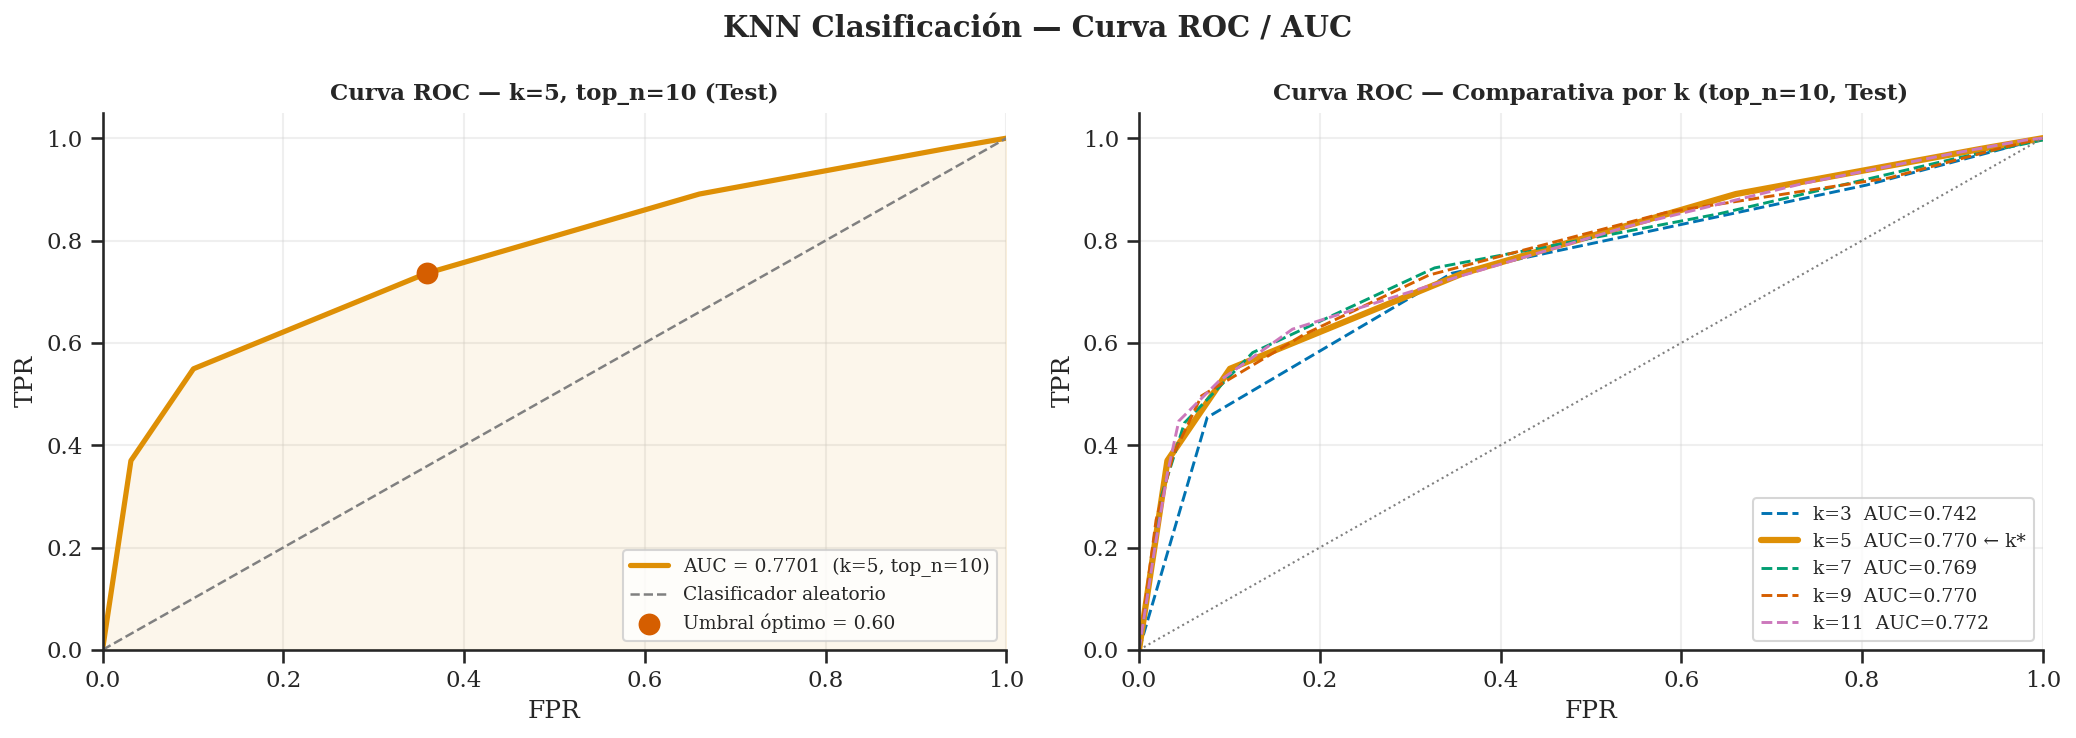

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_test)
roc_auc_best = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color=C_DROPOUT, lw=2.5,
             label=f"AUC = {roc_auc_best:.4f}  (k={best_k}, top_n={best_top_n})")
axes[0].fill_between(fpr, tpr, alpha=0.08, color=C_DROPOUT)
axes[0].plot([0,1],[0,1], color="gray", lw=1.2, linestyle="--",
             label="Clasificador aleatorio")
dist    = np.sqrt(fpr**2 + (1 - tpr)**2)
opt_idx = np.argmin(dist)
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=90, color=C_ACCENT, zorder=5,
                label=f"Umbral óptimo = {thresholds[opt_idx]:.2f}")
axes[0].set(xlim=[0,1], ylim=[0,1.05], xlabel="FPR", ylabel="TPR")
axes[0].set_title(f"Curva ROC — k={best_k}, top_n={best_top_n} (Test)")
axes[0].legend(loc="lower right", fontsize=9); axes[0].grid(alpha=0.3)

palette = sns.color_palette("colorblind", len(K_VALUES))
for idx, k in enumerate(K_VALUES):
    p = make_clf_pipeline(k, best_top_n)
    p.fit(X_trainval_raw, y_clf_trainval)
    fpr_k, tpr_k, _ = roc_curve(y_clf_test, p.predict_proba(X_test_raw)[:, 1])
    axes[1].plot(fpr_k, tpr_k,
                 lw=3.0 if k==best_k else 1.4,
                 linestyle="-" if k==best_k else "--",
                 color=palette[idx],
                 label=f"k={k}  AUC={auc(fpr_k,tpr_k):.3f}" +
                       (" ← k*" if k==best_k else ""))

axes[1].plot([0,1],[0,1], color="gray", lw=1, linestyle=":")
axes[1].set(xlim=[0,1], ylim=[0,1.05], xlabel="FPR", ylabel="TPR")
axes[1].set_title(f"Curva ROC — Comparativa por k (top_n={best_top_n}, Test)")
axes[1].legend(loc="lower right", fontsize=9); axes[1].grid(alpha=0.3)

sns.despine()
plt.suptitle("KNN Clasificación — Curva ROC / AUC",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


### **Impacto de `k` en el Desempeño**

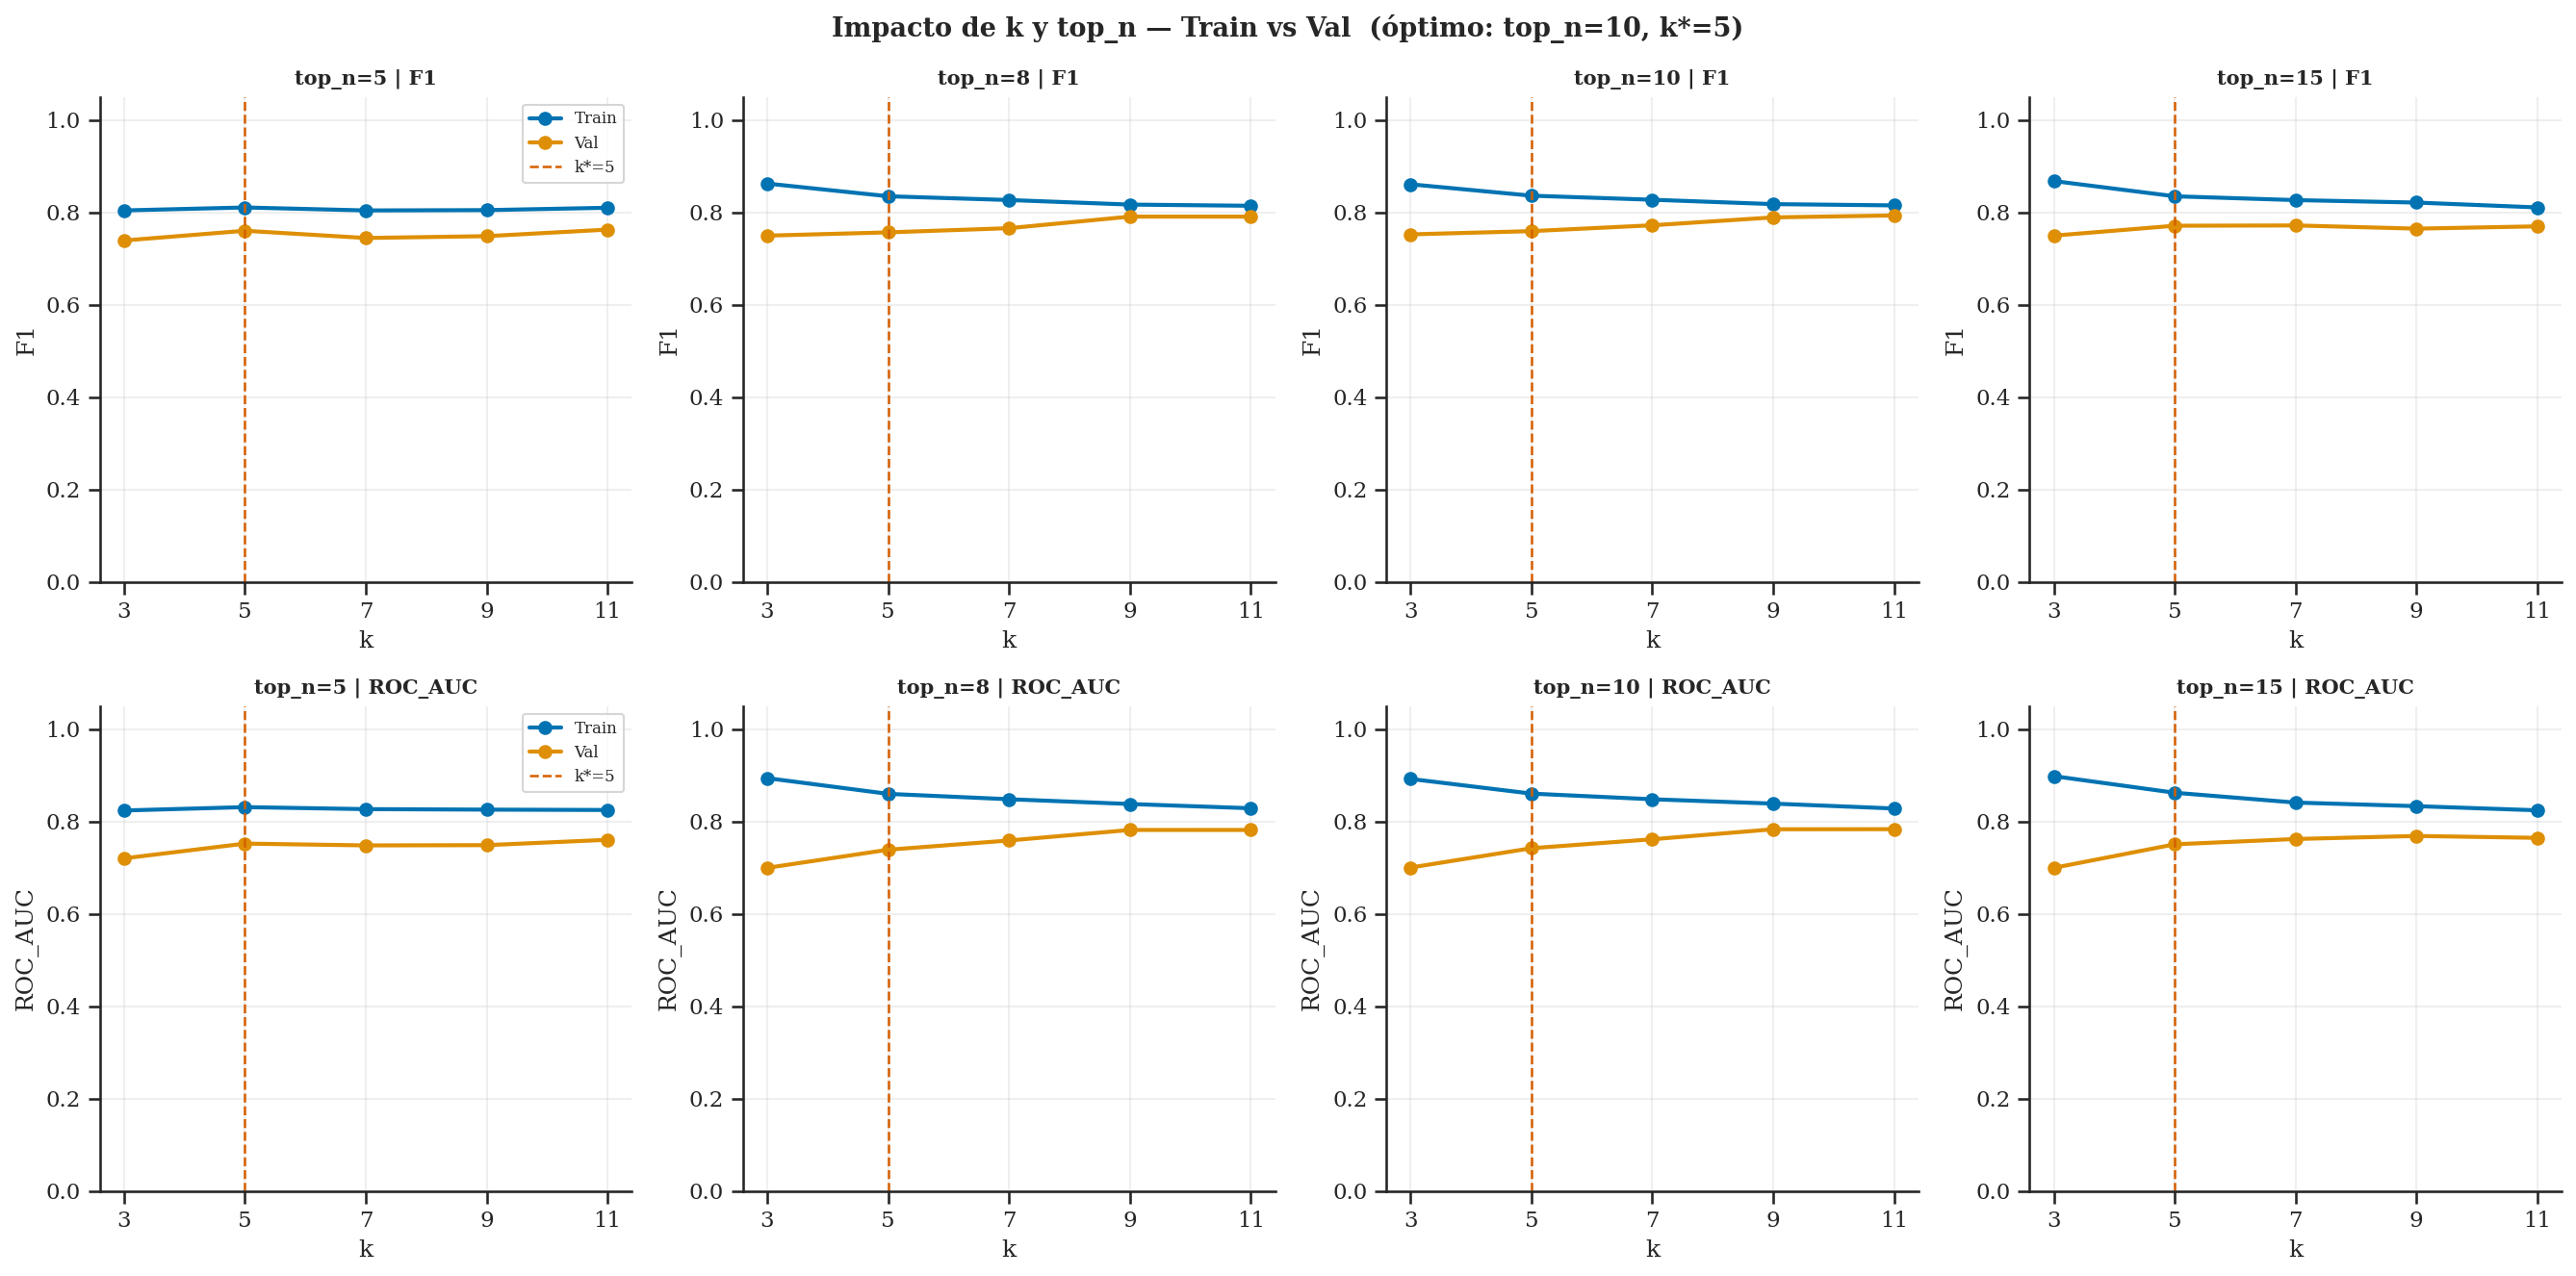


Resumen Val — top_n=10:


,F1,ROC_AUC,Recall
k,,,
3,0.752200,0.700200,0.758800
5,0.759200,0.742000,0.767500
7,0.771900,0.761400,0.793900
9,0.788900,0.783000,0.811400
11,0.793200,0.783200,0.815800


In [50]:
records = []
for top_n in TOPN_VALUES:
    for k in K_VALUES:
        p = make_clf_pipeline(k, top_n)
        p.fit(X_train_raw, y_clf_train)
        for split_name, X_s, y_s in [("Train", X_train_raw, y_clf_train),
                                       ("Val",   X_val_raw,   y_clf_val)]:
            y_p  = p.predict(X_s)
            y_pr = p.predict_proba(X_s)[:, 1]
            records.append({
                "k"       : k,
                "top_n"   : top_n,
                "Split"   : split_name,
                "F1"      : f1_score(y_s, y_p, zero_division=0),
                "ROC_AUC" : roc_auc_score(y_s, y_pr),
                "Recall"  : recall_score(y_s, y_p, zero_division=0),
            })

df_k = pd.DataFrame(records)

fig, axes = plt.subplots(2, len(TOPN_VALUES), figsize=(18, 9))
metrics_plot = ["F1", "ROC_AUC"]

for col, top_n in enumerate(TOPN_VALUES):
    sub = df_k[df_k["top_n"] == top_n]
    for row, met in enumerate(metrics_plot):
        ax = axes[row][col]
        for split, grp in sub.groupby("Split"):
            ax.plot(grp["k"], grp[met], marker="o", lw=2,
                    label=split, color=COLORS_SPLIT[split])
        ax.axvline(best_k, color=C_ACCENT, linestyle="--", lw=1.2,
                   label=f"k*={best_k}" if col==0 else "")
        ax.set(xticks=K_VALUES, ylim=(0, 1.05), xlabel="k", ylabel=met)
        ax.set_title(f"top_n={top_n} | {met}", fontsize=10)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(fontsize=8)

sns.despine()
plt.suptitle(f"Impacto de k y top_n — Train vs Val  "
             f"(óptimo: top_n={best_top_n}, k*={best_k})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\nResumen Val — top_n={best_top_n}:")
display(_booktabs(
    df_k[(df_k["top_n"]==best_top_n) & (df_k["Split"]=="Val")]
    .set_index("k")[["F1","ROC_AUC","Recall"]]
    .round(4)
    .style.highlight_max(axis=0, props="font-weight: bold;")
))